# [LAB-10] 4-3. 분류 성능 평가 모듈화

## #01. 준비작업

### 1. 라이브러리 참조

In [1]:
# 라이브러리 기본 참조
from jussam import load_data
from helper import *

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터 가져오기 + 분류모델 적합

In [2]:
origin = load_data('pima_indians_diabetes_preprocessed')
fit = my_logit.auto_logit(origin, 'Outcome', plot=False, report=False)

📚 피마 인디언 당뇨병 데이터셋에 대한 전처리 버전 - 결측치 처리, 이상치 처리, 라벨링 (출처: 자체 작업)



## #02. 모듈화 기능 확인

### 1. 혼동행렬 시각화

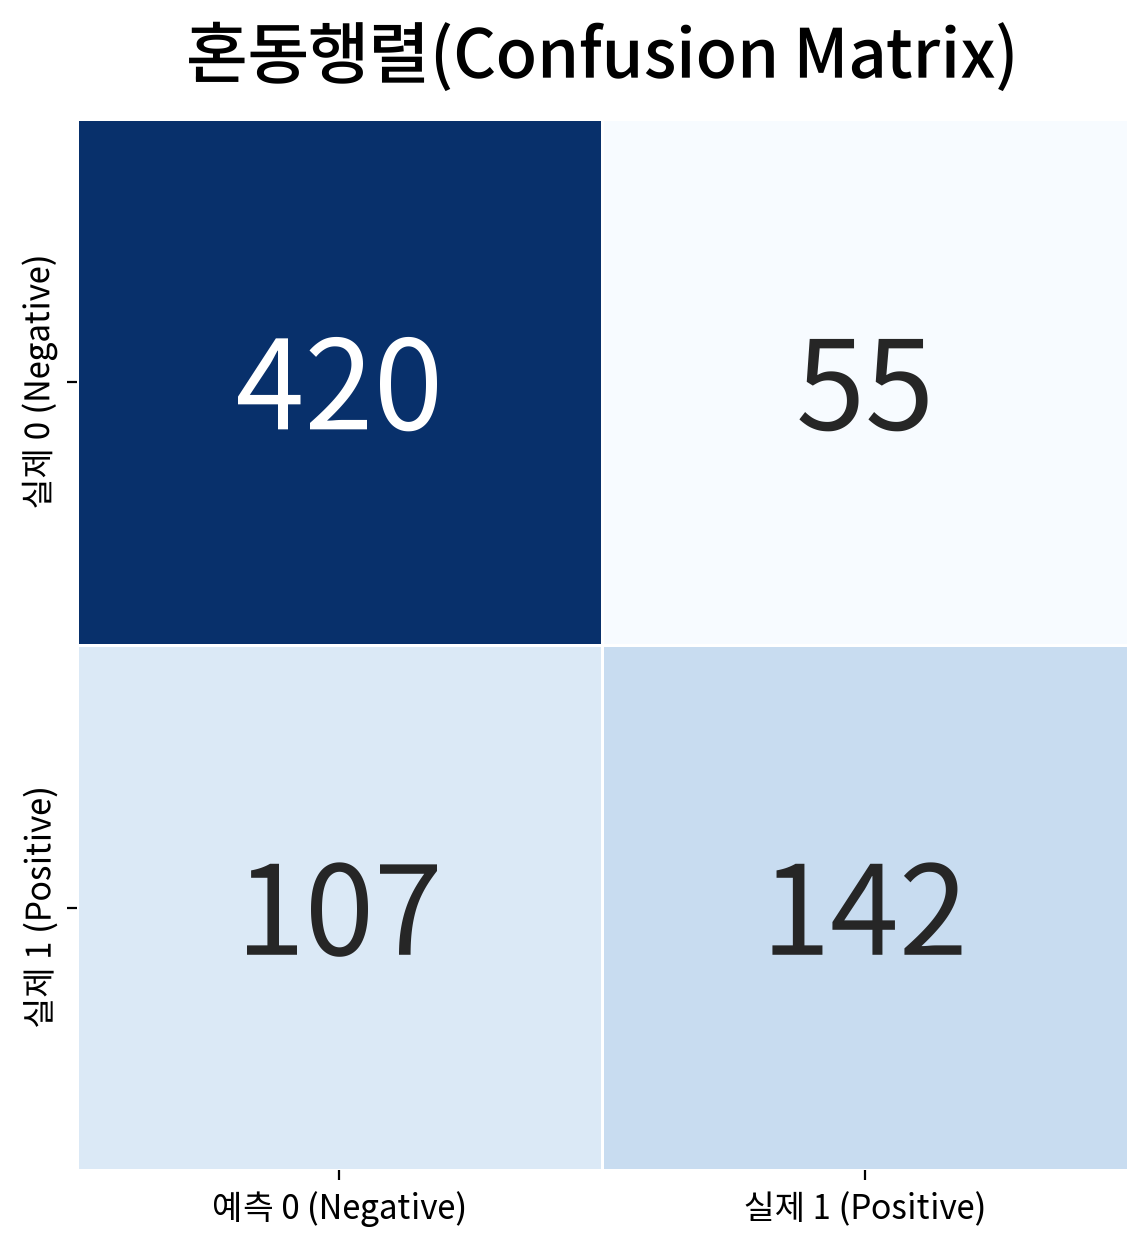

In [3]:
my_logit.plot_confusion(fit)

### 2. ROC 곡선 시각화

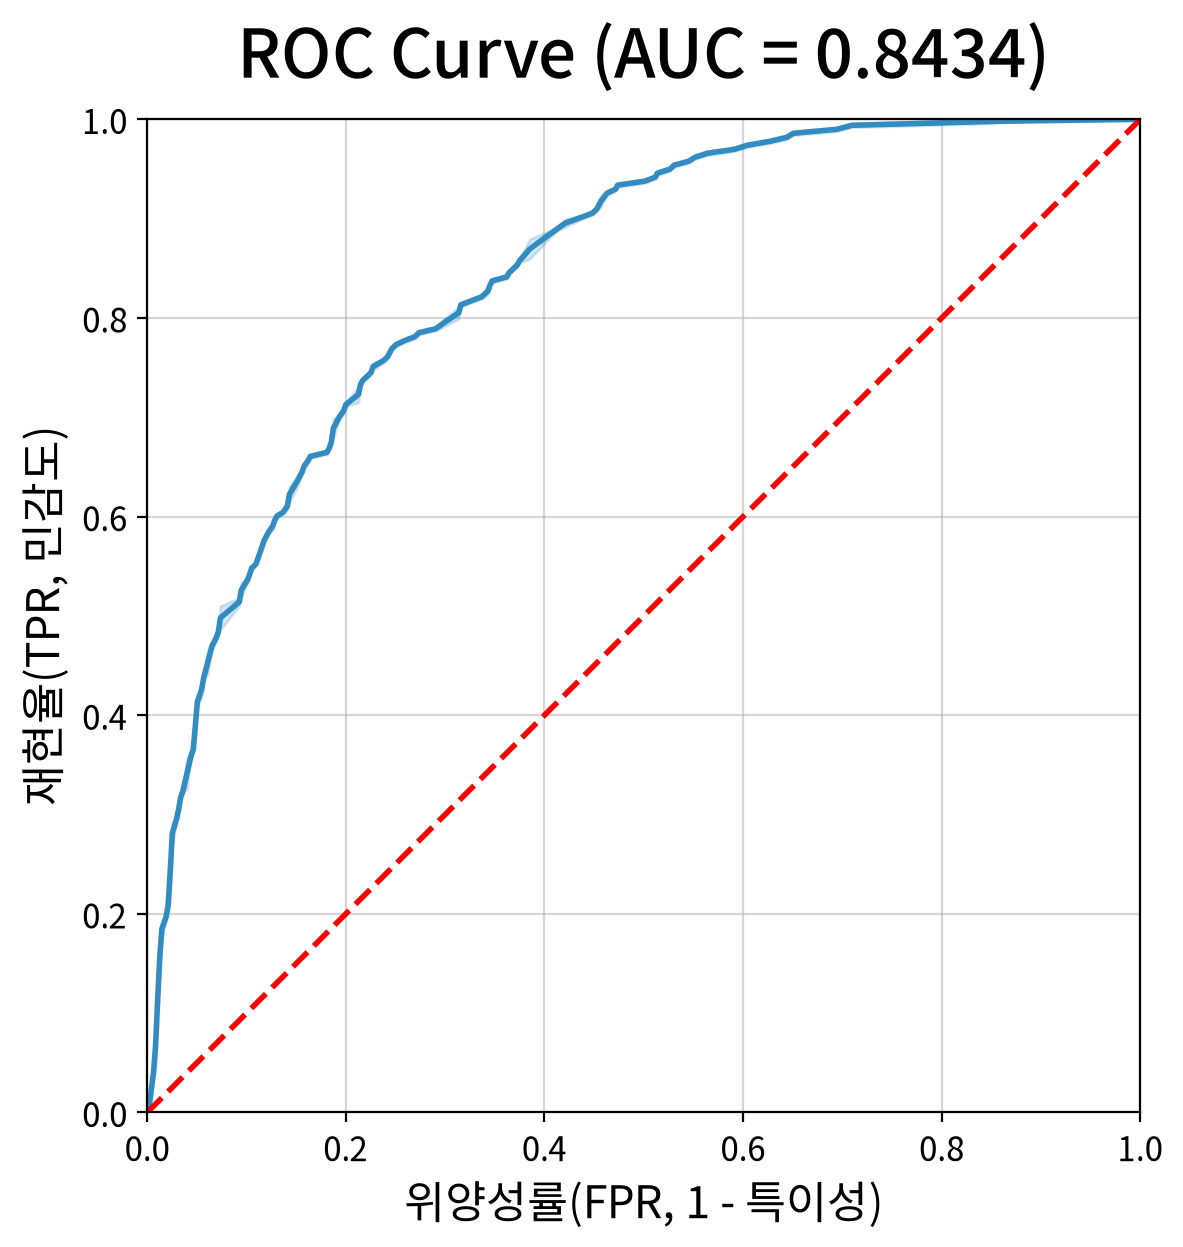

In [4]:
my_logit.plot_roc(fit)

### 3. 분류 성능 평가

,예측 0 (Negative),예측 1 (Positive)
실제 0 (Negative),420,55
실제 1 (Positive),107,142


,정확도(Accuracy),정밀도(Precision),"재현율(Recall, TPR)","위양성율(Fallout,FPR)","특이성(Specificity, TNR)",F1,AUC,AUC 판단,진단오즈비(DOR)
performance,0.776,0.721,0.570,0.116,0.884,0.637,0.843,우수,10.134


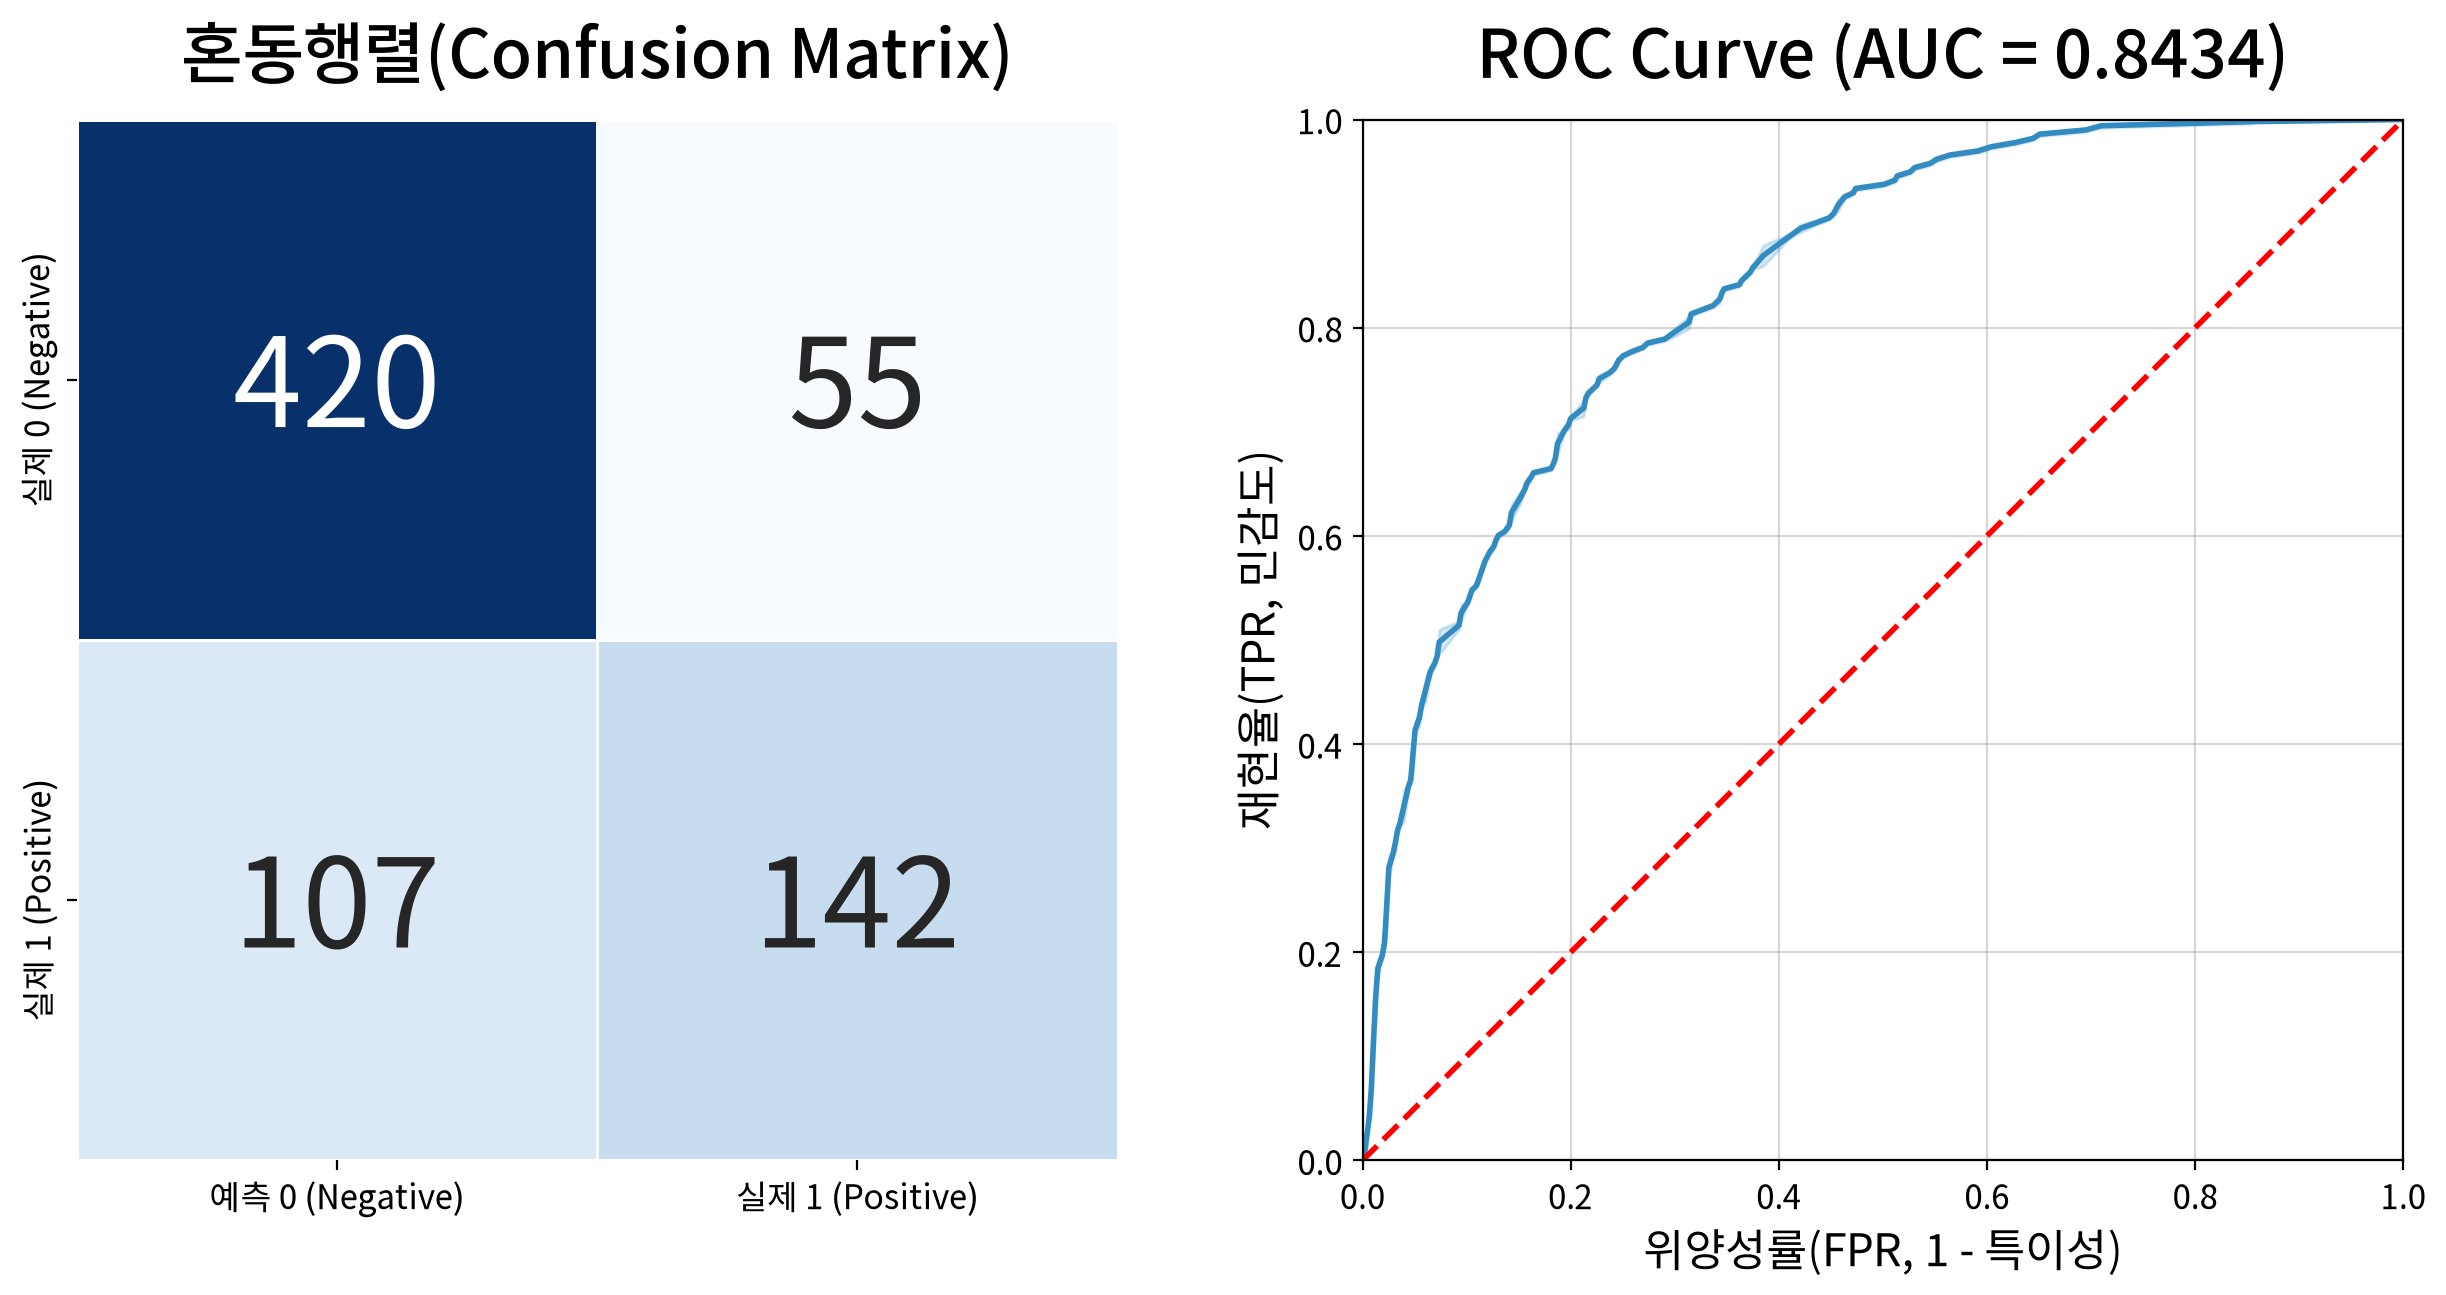

In [5]:
my_logit.report_performance(fit)

#### 연습문제
** 데이터셋 'nursing_grades'
#### 문제 1. 실장님의 "정확도 70%"가 정말 잘한 성적인지 비교할 기준이 필요합니다. 지원자 전원을 무조건 불합격으로만 찍는 모형의 정확도는?
** 정답 ** 0.663
#### 문제 2. 상담에서 가장 아픈 실수는 합격할 수 있었던 지원자에게 "어렵겠다"고 말하는 경우입니다. 임계값 0.5에서 실제 합격인데 불합격으로 예측한 지원자는 몇명인가요?
#### 문제 3. "실제 합격자 가운데 모형이 찾아낸 비율"은 얼마인가요?
#### 문제 4. 특정 임계값 하나가 아니라 모든 임계값을 통틀어 모형의 실력을 요약하는 지표가 있습니다. 성능 평가 결과표는 이 지표에 어떤 판단 등급을 붙였나요?
#### 문제 5. 모형의 판정과 실제 결과가 얼마나 강하게 연결되어있는지를 혼동행렬 네 칸으로 요약한 값은?
#### 문제 6. 놓치는 합격자를 줄여야 합니다. 임계값을 0.3부터 0.7까지 0.1씩 바꿀 때, 정밀도와 재현율을 함께 반영한 점수가 가장 높아지는 임계값은?

In [6]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
q = load_data('nursing_grades')

q1 = q[q['합격여부'] != '보류'].reset_index(drop=True)
print(q1['합격여부'])
q1['합격여부1'] = np.where(q1['합격여부'] == '합격', 1, 0)
display(q1.head(5))
q1.info()
y_real = q1['합격여부1']
count = y_real.value_counts()
ratio = y_real.value_counts(normalize=True)

display(pd.DataFrame({'인원수': count, '비율' : ratio}))



📚 어느 간호학과 대학원에 지원한 학생들에 대한 합격/불합격 여부를 조사한 가상의 데이터(메타데이터 없음)
0      불합격
1       합격
2       합격
3       합격
4      불합격
      ... 
372    불합격
373    불합격
374    불합격
375    불합격
376    불합격
Name: 합격여부, Length: 377, dtype: str


,접수코드,이름,성별,필기점수,학부성적,병원경력,합격여부,합격여부1
0,NRS0001,장은우,남,380,3.610,3,불합격,0
1,NRS0002,최지호,남,660,3.670,3,합격,1
2,NRS0003,김하준,남,800,4.000,1,합격,1
3,NRS0004,임아윤,여,640,3.190,4,합격,1
4,NRS0005,강하준,남,520,2.930,4,불합격,0


<class 'pandas.DataFrame'>
RangeIndex: 377 entries, 0 to 376
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   접수코드    377 non-null    str    
 1   이름      377 non-null    str    
 2   성별      377 non-null    str    
 3   필기점수    377 non-null    int64  
 4   학부성적    377 non-null    float64
 5   병원경력    377 non-null    int64  
 6   합격여부    377 non-null    str    
 7   합격여부1   377 non-null    int64  
dtypes: float64(1), int64(3), str(4)
memory usage: 33.8 KB


,인원수,비율
합격여부1,,
0,250,0.663
1,127,0.337


In [7]:
y_false = np.zeros(len(y_real), dtype=int)
print(f"'무조건 불합격' 정확도는 {accuracy_score(y_real, y_false):.3f}")
print(q1.dtypes)
q2 = 

SyntaxError: invalid syntax (3434117497.py, line 4)

In [ ]:
my_logit.test_linear(fit, origin)

NameError: name 'my_logit' is not defined